In [86]:
#згенеруйте послідовність із 26 випадкових чисел від 0 до 26. 
#Побудуйте графік який зєднує значення кожного сусіда, і знайдіть найбільшу глибину ями між горами

In [ ]:
#Підхід: перебрати всі можливі варіанти. 

In [81]:
#1) генерація випадкових чисел
from random import randint
arr = [randint(0, 26) for _ in range(26)]
x = range(len(arr))
y = arr
print(arr)

[13, 7, 22, 1, 11, 19, 2, 23, 5, 17, 8, 21, 3, 2, 18, 2, 1, 21, 9, 3, 1, 6, 6, 19, 0, 17]


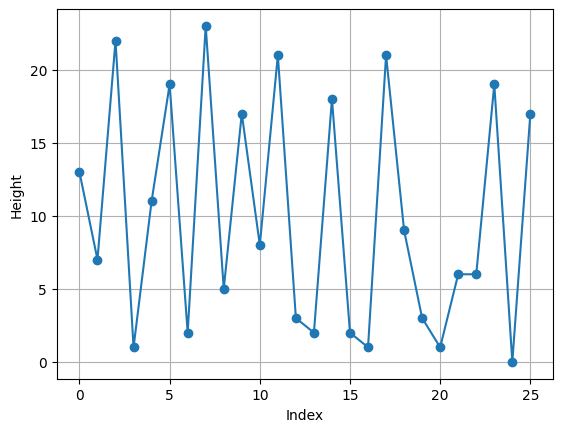

In [82]:
#2) побудова лінійного графіку
import matplotlib.pyplot as plt
plt.plot(x, y, '-o')
plt.grid(True)
plt.xlabel("Index")
plt.ylabel("Height")
plt.show()

In [85]:
#3)пошук найглибшого озера
max_depth = 0 # змінна для запису глибини
l_idx = 0 # змінна для збереження меж озера з лівого боку
r_idx = 0 # змінна для збереження меж озера з правого боку
best_water_top = 0 # змінні для запам'ятовування верхньої і нижньої не проливної ями (верх)
best_water_bottom = 0 # (низ)
#шукаємо береги
n = len(arr)
for i in range(n):  #i лівий берег
    for j in range(i+2, n):  # j правий берег
        water_level = min(arr[i], arr[j]) #визначення рівня води по нижчому з двох берегів
        inner_part = arr[i+1 : j] #внутрішня частина

#перевірка, чи всі точки всередині нижчі за рівень води?
        first_condition = True
        for h in inner_part:
            if h >= water_level:
                first_condition = False
                break

#якщо озеро суцільне, рахується глибина
        if first_condition:
            lowest_point = min(inner_part) #depth_here змінна для глибини поточної ями
            depth_here = water_level - lowest_point
#якщо глибина більша за попередній рекорд
            if depth_here > max_depth:
                max_depth = depth_here
                l_idx = i
                r_idx = j
                # це просто щоб запам'ятати значення для майбутнього графіка при виході з циклу
                best_water_top = water_level
                best_water_bottom = lowest_point
            print(f"|Глибина найглибшого озера: {max_depth}|", f"|лівий берег:{l_idx}|", f"|правий берег:{r_idx}|",f"|верхня межа озера:{best_water_top}|",f"|нижня межа озера:{best_water_bottom}|")

|Глибина найглибшого озера: 6| |лівий берег:0| |правий берег:2| |верхня межа озера:13| |нижня межа озера:7|
|Глибина найглибшого озера: 10| |лівий берег:2| |правий берег:4| |верхня межа озера:11| |нижня межа озера:1|
|Глибина найглибшого озера: 18| |лівий берег:2| |правий берег:5| |верхня межа озера:19| |нижня межа озера:1|
|Глибина найглибшого озера: 21| |лівий берег:2| |правий берег:7| |верхня межа озера:22| |нижня межа озера:1|
|Глибина найглибшого озера: 21| |лівий берег:2| |правий берег:7| |верхня межа озера:22| |нижня межа озера:1|
|Глибина найглибшого озера: 21| |лівий берег:2| |правий берег:7| |верхня межа озера:22| |нижня межа озера:1|
|Глибина найглибшого озера: 21| |лівий берег:2| |правий берег:7| |верхня межа озера:22| |нижня межа озера:1|
|Глибина найглибшого озера: 21| |лівий берег:2| |правий берег:7| |верхня межа озера:22| |нижня межа озера:1|
|Глибина найглибшого озера: 21| |лівий берег:2| |правий берег:7| |верхня межа озера:22| |нижня межа озера:1|
|Глибина найглибшого

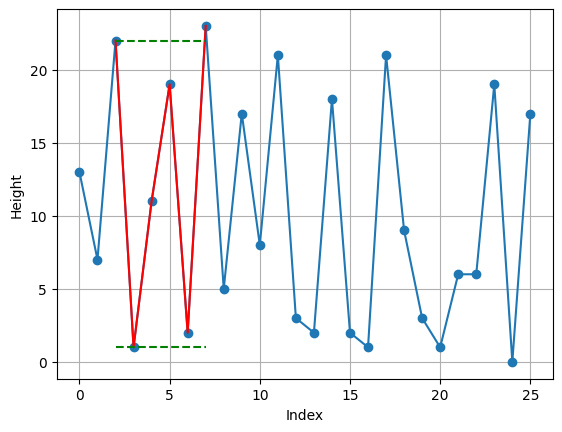

In [84]:
#4) Візуалізація результатів
# малювання старого доброго графіка
plt.plot(x, y, '-o', label='Mountains')
plt.grid(True)
plt.xlabel("Index")
plt.ylabel("Height")


# малювання виділеної червоної території
lake_x = x[l_idx : r_idx+1] #координати x для озера
lake_y = y[l_idx : r_idx+1] #координати y для озера
plt.plot(lake_x, lake_y, color='red')
#побудова зелених меж, в стилі перерваних ліній
plt.hlines(y=best_water_top, xmin=l_idx, xmax=r_idx, color='green', linestyle='--')
plt.hlines(y=best_water_bottom, xmin=l_idx, xmax=r_idx, color='green', linestyle='--')
plt.show()